In [1]:
!pip install catboost

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


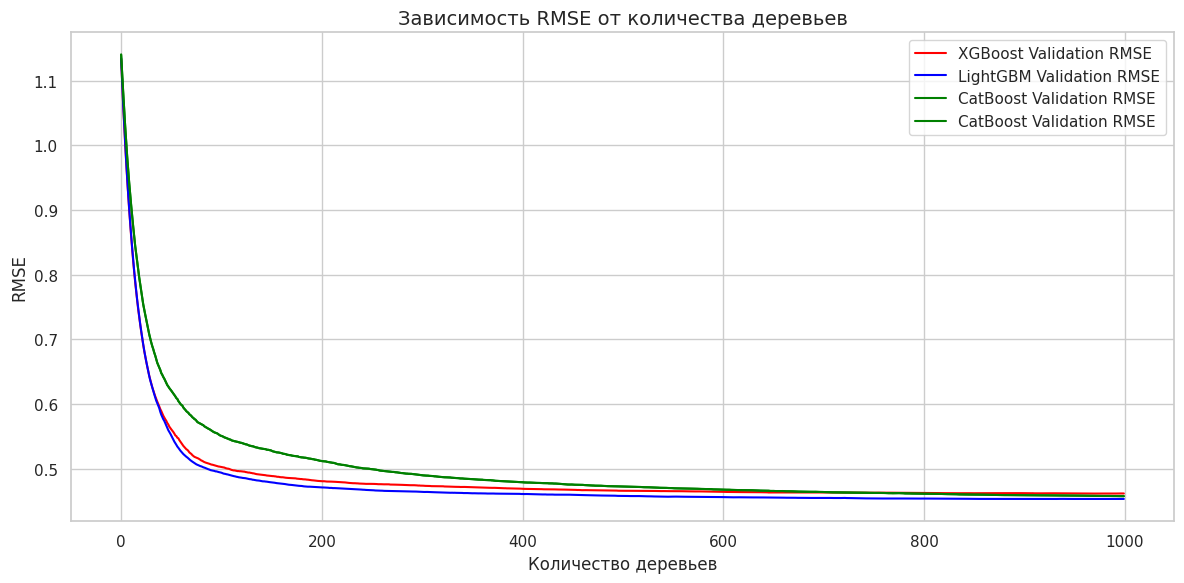

In [4]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
SELECTED_N_ESTIMATORS = 400

In [15]:
class MyBoost:
    def __init__(self, n_estimators=400, lr=0.05, depth=7, seed=42, max_sample=1.0,
                 colsample_bytree=1.0, bootstrap=True, eval_metric='rmse', cat_features=None) -> None:
        self.n = n_estimators
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.max_sample = max_sample
        self.colsample_bytree = colsample_bytree
        self.bootstrap = bootstrap
        self.trees = []
        self.sample_index = []
        self.ind_space = []
        self.eval_metric = eval_metric
        self.evals_result_ = {'validation_0': {}}
        self.n_feature = None
        self.cat_features = cat_features
        self.cat_encodings_ = {}

    def get_ind_sample(self, n):
        sample_size = max(1, int(self.max_sample * n))
        if self.bootstrap:
            index = np.random.choice(n, size=sample_size, replace=True)
        else:
            index = np.random.choice(n, size=sample_size, replace=False)
        return index

    def get_rand_subspace(self, n):
        k_target = max(1, int(n * self.colsample_bytree))
        return np.random.choice(n, k_target, replace=False)

    def compute_metric(self, y_true, y_pred):
        if self.eval_metric == 'rmse':
            return np.sqrt(np.mean((y_true - y_pred) ** 2))
        elif self.eval_metric == 'mse':
            return np.mean((y_true - y_pred) ** 2)
        elif self.eval_metric == 'mae':
            return np.mean(np.abs(y_true - y_pred))
        else:
            raise ValueError(f"Unknown metric: {self.eval_metric}")

    def encode_categoricals(self, X, y, X_apply):  # ← ИСПРАВЛЕНО: правильное название
        X_apply = X_apply.copy()
        global_mean = y.mean()

        for col in self.cat_features:
            mapping = {}
            for category in np.unique(X[:, col]):
                mask = X[:, col] == category
                mapping[category] = y[mask].mean()

            self.cat_encodings_[col] = mapping
            X_apply[:, col] = np.array([mapping.get(val, global_mean) for val in X_apply[:, col]])

        return X_apply

    def fit(self, X, y, eval_set=None):
        self.initial_leaf = y.mean()
        self.n_feature = X.shape[1]
        predictions = np.zeros(len(y)) + self.initial_leaf

        if self.cat_features is not None:
            X = self.encode_categoricals(X, y, X)

        if eval_set is not None:
            X_val, y_val = eval_set[0]
            val_predictions = np.zeros(len(y_val)) + self.initial_leaf
            self.evals_result_['validation_0'][self.eval_metric] = []

        for i in range(self.n):
            antigrad = y - predictions

            if self.colsample_bytree < 1.0:
                index_space = self.get_rand_subspace(X.shape[1])
                X_tree = X[:, index_space]
            else:
                index_space = np.arange(X.shape[1])
                X_tree = X

            if self.max_sample < 1.0:
                index = self.get_ind_sample(len(y))
                X_sample = X_tree[index]
                antigrad_sample = antigrad[index]
            else:
                index = None
                X_sample = X_tree
                antigrad_sample = antigrad

            self.sample_index.append(index)
            self.ind_space.append(index_space)

            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed + i, criterion="friedman_mse")
            tree.fit(X_sample, antigrad_sample)
            self.trees.append(tree)

            predictions += tree.predict(X[:, index_space]) * self.lr

            if eval_set is not None:
                val_predictions += tree.predict(X_val[:, index_space]) * self.lr
                metric_value = self.compute_metric(y_val, val_predictions)
                self.evals_result_['validation_0'][self.eval_metric].append(metric_value)
        return self

    @property
    def feature_importances_(self):
        n_features = np.zeros(self.n_feature)
        for tree, ind_space in zip(self.trees, self.ind_space):
            n_features[ind_space] += tree.feature_importances_
        n_features = n_features / (self.n)
        return n_features

    def predict(self, samples):
        predictions = np.zeros(len(samples)) + self.initial_leaf

        if self.cat_features:
            samples = samples.copy()
            for col in self.cat_features:
                mapping = self.cat_encodings_[col]
                global_mean = self.initial_leaf
                samples[:, col] = np.array([mapping.get(val, global_mean) for val in samples[:, col]])

        for i in range(self.n):
            index = self.ind_space[i]
            samples_subspace = samples[:, index]
            predictions += self.lr * self.trees[i].predict(samples_subspace)

        return predictions

In [17]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])


grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

grid_my = {
    'lr': [0.05, 0.1],
    'depth': [5, 7],
    'max_sample': [0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        elif model_name == 'CatBoost':
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)
        else:
           model=MyBoost(**params,n_estimators=SELECTED_N_ESTIMATORS, seed=42)

        model.fit(X_train.values, y_train)
        preds = model.predict(X_val.values)

        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)
best_params_dict['MyBoost'] = simple_grid_search('MyBoost', grid_my)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4621
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}

--- Запуск Grid Search для MyBoost ---
Лучший Validation RMSE: 0.4669
Лучшие параметры: {'depth': 7, 'lr': 0.05, 'max_sample': 0.8}



In [21]:
results = []

# Для numpy массивов используем np.concatenate

y_train_full = np.concatenate([y_train, y_val])
X_train_full = pd.concat([X_train, X_val]).values
X_test_np = X_test.values

for name in ['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':

        mapped_params = {
          'lr': params['lr'],
          'depth': params['depth'],
          'max_sample': params['max_sample'] }
        model = MyBoost(n_estimators=SELECTED_N_ESTIMATORS, seed=42, **mapped_params)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42,
                                     thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test_np)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,4.318,0.2912,0.4476,0.8471
1,LightGBM,0.609,0.2862,0.4379,0.8537
2,CatBoost,2.330,0.2967,0.4493,0.8460
3,MyBoost,36.689,0.2951,0.4521,0.8441


По результатам лучшей моделью получилась LightGBM. MyBoost- реализована нормально, так как метрика $R^2$ отклоняется меньше чем на 0.05.Модель сильно проигрывает только по времени выполнения, потому что не оптимизирована.

Реализованы ключевые компоненты бустинга:
* обучение на антиградиенте
* shrinkage (learning rate)
* стохастичность (subsample, colsample)
* базовые деревья решений